# Bagging - Practice Lab

## Bootstrap Aggregating (Bagging) for classification with Python

Estimated time needed: **45** minutes

### Objectives

After completing this lab you will be able to:

*   Understand Bootstrap sampling
*   Understand  Model Instability
*   Apply Bagging
*   Understand when to use Bagging


In this notebook, you will learn the process of Bagging  (Bootstrap Aggregation)  models for classification. Bagging is a method for generating multiple model versions and aggregating the ensemble of models to make a single prediction. For classification, aggregation performs majority vote when predicting a class. The various versions of the model are formed by performing Bootstrap sampling of the training set and using these to train each model in the ensemble .


<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#preprocessing">Data pre-processing and selection</a></li>
        <li><a href="https://#modeling">Modeling (Logistic Regression with Scikit-learn)</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#practice">Practice</a></li>
    </ol>
</div>
<br>
<hr>


Let's first import required libraries:


In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn import metrics
from tqdm import tqdm # Give loops a progress bar

This function calculates the train and test accuracy of a model


In [2]:
def get_accuracy(X_train, X_test, y_train, y_test, model):
    return  {"test Accuracy":metrics.accuracy_score(y_test, model.predict(X_test)),"train Accuracy": metrics.accuracy_score(y_train, model.predict(X_train))}

This function creates visualizations of decision trees


In [3]:
# Plot tree helper libraries
from  io import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree


def plot_tree(model,filename = "tree.png"):
    #global churn_df 

    dot_data = StringIO()
  

    featureNames = [colunm  for colunm in churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']].columns]
    out=tree.export_graphviz(model,feature_names=featureNames, out_file=dot_data, class_names= ['left','stay'], filled=True,  special_characters=True,rotate=False)  
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
    graph.write_png(filename)
    img = mpimg.imread(filename)
    plt.figure(figsize=(100, 200))
    plt.imshow(img,interpolation='nearest')

This function creates a graph of training accuracy vs how many estimators (Decision Trees) a BaggingClassifier uses


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

def get_accuracy_bag(X,y,title,times=20,xlabel='Number Estimators'):
    #Iterate through different number of estimators and average out the results  


    N_estimators=[n for n in range(1,70)]
    times=20
    train_acc=np.zeros((times,len(N_estimators)))
    test_acc=np.zeros((times,len(N_estimators)))
    
    train_time=np.zeros((times,len(N_estimators)))
    test_time=np.zeros((times,len(N_estimators)))
     #average out the results
    for n in tqdm(range(times)):
        X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3)
        for n_estimators in N_estimators:
            #Iterate through different number of estimators and average out the results   
        
            Bag= BaggingClassifier(estimator=DecisionTreeClassifier(criterion="entropy", max_depth = 10),n_estimators=n_estimators,bootstrap=True,random_state=0)
            Bag.fit(X_train,y_train)
          
            
             
            Accuracy=get_accuracy(X_train, X_test, y_train, y_test,  Bag)
           
            
            
  
            train_acc[n,n_estimators-1]=Accuracy['train Accuracy']
            test_acc[n,n_estimators-1]=Accuracy['test Accuracy']
        
        
        
    fig, ax1 = plt.subplots()

    ax2 = ax1.twinx()
    ax1.plot(train_acc.mean(axis=0))
    ax2.plot(test_acc.mean(axis=0),c='r')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel('Training accuracy',color='b')
    ax2.set_ylabel('Testing accuracy', color='r')
    plt.title(title)
    plt.show()
    
   

## Customer churn

A telecommunications company is concerned about the number of customers leaving their land-line business for cable competitors. They need to understand who is leaving. Imagine that you are an analyst at this company and you have to find out why


### About the dataset

We will use a telecommunications dataset for predicting customer churn. This is a historical customer dataset where each row represents one customer. The data is relatively easy to understand, and you may uncover insights you can use immediately. Typically it is less expensive to keep customers than acquire new ones, so the focus of this analysis is to predict the customers who will stay with the company.

This data set provides information to help you predict what behavior will help you to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.

The dataset includes information about:

*   Customers who left within the last month – the column is called Churn
*   Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
*   Customer account information – how long they had been a customer, contract, payment method, paperless billing, monthly charges, and total charges
*   Demographic info about customers – gender, age range, and if they have partners and dependents


### Load Data From CSV File


In [5]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"

churn_df = pd.read_csv("data/ChurnData.csv")
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


<h2 id="preprocessing">Data pre-processing and selection</h2>


Let's select some features for the modeling. Also, we change the target data type to be an integer, as it is a requirement by the skitlearn algorithm:


In [6]:
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',   'callcard', 'wireless','churn']]
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


## Practice

How many rows and columns are in this dataset in total? What are the names of columns?


In [7]:
print(churn_df.shape)
print(churn_df.columns)

(200, 10)
Index(['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip',
       'callcard', 'wireless', 'churn'],
      dtype='str')


## Bootstrap Sampling

Bootstrap Sampling is a method that involves drawing of sample data repeatedly with replacement from a data source to estimate a model parameter. Scikit-learn has methods for Bagging but its helpful to understand Bootstrap sampling.  We will import <code>resample</code>


In [8]:
from sklearn.utils import resample

Consider the five rows of data:


In [9]:
churn_df[0:5]

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


We can perform a bootstrap sample using the function <code>resample</code>; we see the dataset is the same size, but some rows are repeated:


In [10]:
resample(churn_df[0:5])

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1


We can repeat the process randomly drawing several other rows


In [11]:
resample(churn_df[0:5])

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


## Train/Test dataset


Let's define X, and y for our dataset:


In [12]:
X = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']]

X.head()

,tenure,age,address,income,ed,employ,equip
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0


In [13]:
y = churn_df['churn']
y.head()

0    1
1    1
2    0
3    0
4    0
Name: churn, dtype: int64

## Train/Test dataset


We split our dataset into train and test set:


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=0)
print ('Train set', X_train.shape,  y_train.shape)
print ('Test set', X_test.shape,  y_test.shape)

Train set (140, 7) (140,)
Test set (60, 7) (60,)


<h2 id="modeling">Decision  Tree Classifier  with Scikit-learn</h2>


A Decision  tree Classifier classifies a sample by learning simple decision rules inferred from the data. One problem with Decision  Tree Classifiers is overfitting; they do well with the training data, but they do not Generalize well. Trees have low bias and high variance; as such, they are a prime candidate for Bagging. Instability is another term used to describe models that overfit. Instability is characterized by a slight change in the training set that causes a drastic change in the model.  Let's show that Decision tree Classifiers are unstable.


Let's load the DecisionTreeClassifier modle in   <coode>sklearn</code>


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

We create and train a tree with a max depth of  5


In [16]:
max_depth=5
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=10)
Tree = DecisionTreeClassifier(criterion="entropy", max_depth = max_depth,random_state=10)
Tree
Tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Now we can predict using our test set:


In [17]:
yhat = Tree.predict(X_test)
yhat

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

We see the test error is much larger than the training error:


In [18]:
get_accuracy(X_train, X_test, y_train, y_test,  Tree)

{'test Accuracy': 0.6166666666666667, 'train Accuracy': 0.9071428571428571}

We can plot the nodes of the tree:


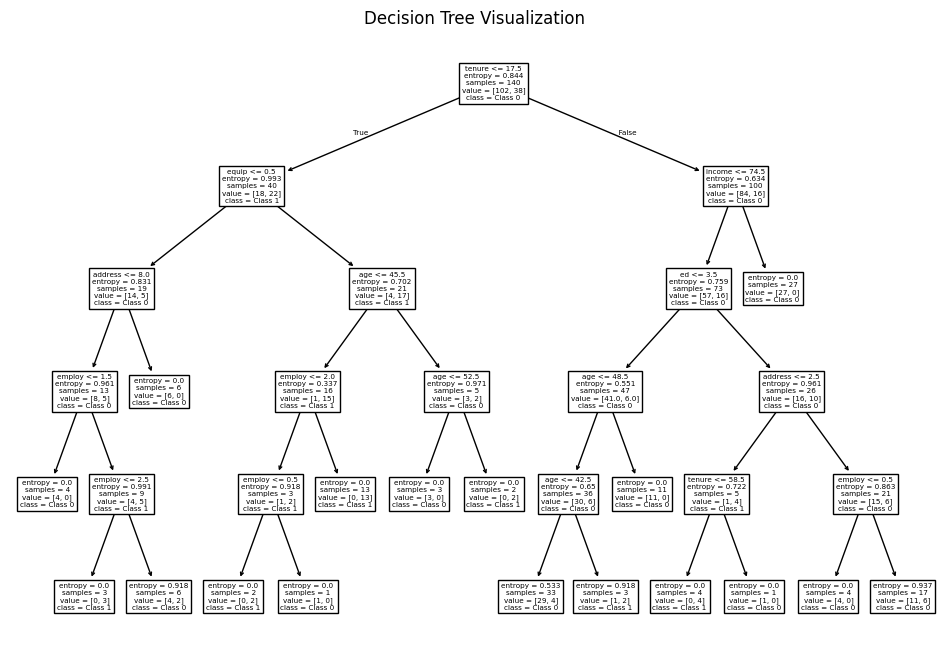

In [19]:
# Adjust the tree plot without 'filled' argument if necessary
plt.figure(figsize=(12, 8))
plot_tree(Tree, 
          feature_names=X.columns,  # Make sure this is a DataFrame; replace with list if it's not
          class_names=['Class 0', 'Class 1'])  # Replace with actual class names

plt.title('Decision Tree Visualization')
plt.savefig("tree.png")
plt.show()

We can repeat the process but sampling different data points from the same dataset.  We see the tree still suffers from overfitting; in addition, the new tree is entirely different.


{'test Accuracy': 0.65, 'train Accuracy': 0.9357142857142857}


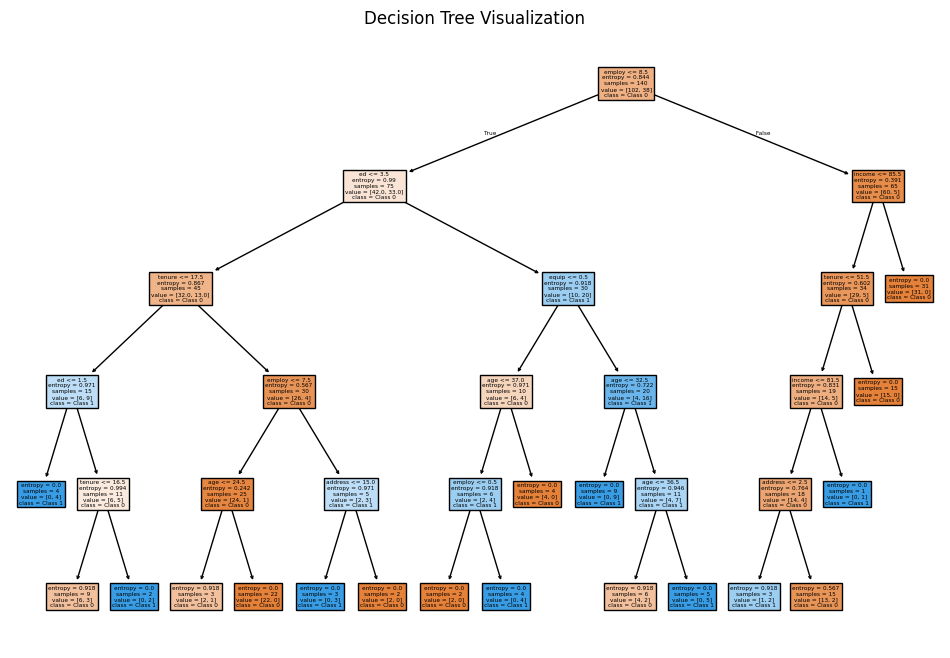

In [20]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=5)
Tree = DecisionTreeClassifier(criterion="entropy", max_depth = max_depth,random_state=8)
Tree.fit(X_train,y_train)
print(get_accuracy(X_train, X_test, y_train, y_test,  Tree))
plt.figure(figsize=(12, 8))  # Set figure size
plot_tree(Tree, 
          filled=True, 
          feature_names=X.columns,  # Replace with actual feature names if X is not a DataFrame
          class_names=['Class 0', 'Class 1'])  # Replace with actual class names

# Save the tree as an image
plt.title('Decision Tree Visualization')
plt.savefig("tree1.png")
plt.show()

<h2 id="evaluation">Bagging  for classification with  Scikit-learn</h2>
A Bagging classifier is an ensemble model that trains  base classifiers  on random subsets   of the original dataset  (Bootstrap Sampling by default), and then aggregate their individual predictions by voting. We import the module:


In [21]:
from sklearn.ensemble import BaggingClassifier

Bagging improves models that suffer from overfitting; they do well on the training data, but they do not Generalize well. Decision Trees are a prime candidate for this reason, in addition, they are fast to train; We create a <code>BaggingClassifier</code> object,  with a Decision Tree as the <code>estimator</code>


In [22]:
Bag = BaggingClassifier(estimator=DecisionTreeClassifier(criterion="entropy", max_depth = 4, random_state=2), n_estimators=30, random_state=0, bootstrap=True)

We fit the model:


In [23]:
Bag.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...andom_state=2)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",30
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


The method <code>predict</code>  aggregates the predictions by voting:


In [24]:
Bag.predict(X_test)

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1])

We see the training accuracy is slightly better but the test accuracy improves  dramatically:


In [25]:
print(get_accuracy(X_train, X_test, y_train, y_test,  Bag))

{'test Accuracy': 0.7, 'train Accuracy': 0.9071428571428571}


Here we can see the impact of adding more estimators (Decision Trees) using in Bagging on the testing and training accuracy


100%|██████████| 20/20 [01:00<00:00,  3.01s/it]


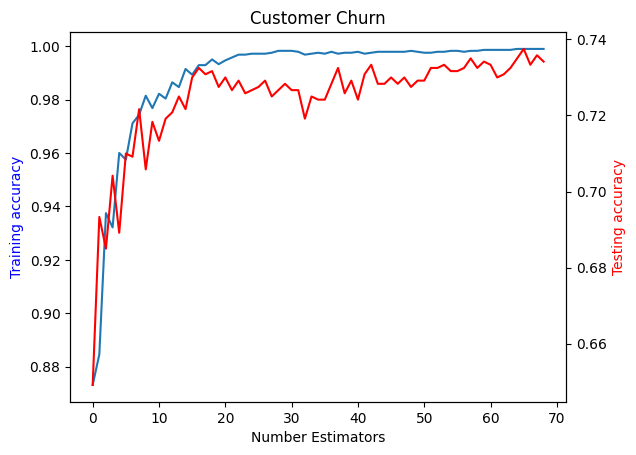

In [26]:
get_accuracy_bag(X, y, "Customer Churn")

## Low Variance Example


Bagging does not improve result if the model has low Variance i.e. does reasonably well on the test and training data. Consider the SVM; the accuracy on the tests data and training data are similar


In [27]:
from sklearn.svm import SVC

clf=SVC(kernel='linear',gamma='scale')
clf.fit(X_train, y_train) 
print(get_accuracy(X_train, X_test, y_train, y_test,  clf))

{'test Accuracy': 0.7166666666666667, 'train Accuracy': 0.7642857142857142}


Bagging the SVM does almost nothing:


In [28]:
Bag = BaggingClassifier(estimator=SVC(kernel='linear',gamma='scale'),n_estimators=10,random_state=0,bootstrap=True)
Bag.fit(X_train,y_train)
print(get_accuracy(X_train, X_test, y_train, y_test,  Bag))

{'test Accuracy': 0.7, 'train Accuracy': 0.7785714285714286}


<BR>

___

<BR>

<h2 id="practice">Practice: Cancer data</h2>

The example is based on a dataset that is publicly available from the UCI Machine Learning Repository (Asuncion and Newman, 2007)[[http://mlearn.ics.uci.edu/MLRepository.html](http://mlearn.ics.uci.edu/MLRepository.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2022-01-01)]. The dataset consists of several hundred human cell sample records, each of which contains the values of a set of cell characteristics. The fields in each record are:

| Field name  | Description                 |
| ----------- | --------------------------- |
| ID          | Clump thickness             |
| Clump       | Clump thickness             |
| UnifSize    | Uniformity of cell size     |
| UnifShape   | Uniformity of cell shape    |
| MargAdh     | Marginal adhesion           |
| SingEpiSize | Single epithelial cell size |
| BareNuc     | Bare nuclei                 |
| BlandChrom  | Bland chromatin             |
| NormNucl    | Normal nucleoli             |
| Mit         | Mitoses                     |
| Class       | Benign or malignant         |

<br>
<br>

Let's load the dataset:


In [29]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/cell_samples.csv"

df = pd.read_csv("data/cell_samples.csv")

df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Now lets remove rows that have a ? in the `BareNuc` column


In [30]:
df = df[df["BareNuc"] != "?"]

Now lets define the X and y for our dataset


In [31]:
X =  df[['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]

X.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1


In [32]:
y = df['Class']

y.head()

0    2
1    2
2    2
3    2
4    2
Name: Class, dtype: int64

Now lets split our data into training and testing data with a 80/20 split


In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)


Now to determine the best parameters for `n_estimators` and the `max_depth` of the `estimator` we will use `GridSearchCV`


In [34]:
from sklearn.model_selection import GridSearchCV

We can use GridSearch for Exhaustive search over specified parameter values. To  alter the base  model; we add the double underscore and the attribute value:

Here we are searching odd numbers from 1 to 39 for `n_estimators` and odd numbers from 1 to 20 for `max_depth` in the `estimator`


In [35]:
param_grid = {'n_estimators': [2*n+1 for n in range(20)],
     'estimator__max_depth' : [2*n+1 for n in range(10) ] }

Create a `BaggingClassifier` object called `Bag` with the `estimator` set to a `DecisionTreeClassifier` object where `random_state` = 0 and `bootstrap` = True


In [36]:
Bag = BaggingClassifier(estimator = DecisionTreeClassifier(), random_state=0, bootstrap=True)

Now we create a `GridSearchCV` object and search for the best parameters according to our `parameter_grid`


In [37]:
search = GridSearchCV(estimator=Bag, param_grid=param_grid, scoring='accuracy', cv=3)

In [38]:
search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 3, ...], 'n_estimators': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

We can see the best accuracy score of the searched parameters was ~97%


In [39]:
search.best_score_

np.float64(0.9688644688644689)

We can also see the parameters that resulted in the best score


In [40]:
search.best_params_

{'estimator__max_depth': 5, 'n_estimators': 11}

And we can see the testing and training accuracy of the best estimator


In [41]:
print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 0.9708029197080292, 'train Accuracy': 0.9853479853479854}


Below we can see a graph of testing and training accuracy holding the `max_depth` of the `estimator` at 10 and varying the number of estimators. We can see that it is extremely close to the accuracy of the `best_estimator` we found using `GridSearchCV`


100%|██████████| 20/20 [01:12<00:00,  3.62s/it]


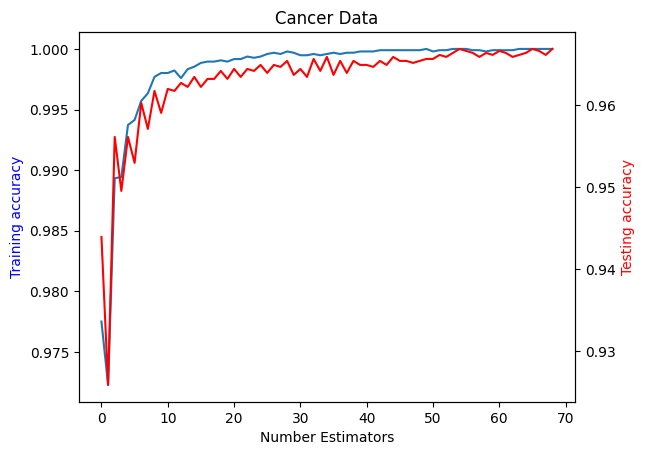

In [42]:
get_accuracy_bag(X, y, "Cancer Data")

<BR>

___

<BR>

<h2 id="practice">Practice: During their course of treatment</h2>


Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.

Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.

It is a sample of multiclass classifier, and you can use the training part of the dataset to build a decision tree, and then use it to predict the class of a unknown patient, or to prescribe a drug to a new patient.


In [43]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv"

df = pd.read_csv("data/drug200.csv", delimiter=",")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


Lets create the X and y for our dataset


In [44]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [45]:
y = df["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: str

Now lets use a `LabelEncoder` to turn categorical features into numerical


In [46]:
le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F','M'])
X[:,1] = le_sex.transform(X[:,1]) 

In [47]:
le_BP = preprocessing.LabelEncoder()
le_BP.fit([ 'LOW', 'NORMAL', 'HIGH'])
X[:,2] = le_BP.transform(X[:,2])

In [48]:
le_Chol = preprocessing.LabelEncoder()
le_Chol.fit([ 'NORMAL', 'HIGH'])
X[:,3] = le_Chol.transform(X[:,3]) 

In [49]:
X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

Split the data into training and testing data with a 80/20 split


In [50]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (160, 5) (160,)
Test set: (40, 5) (40,)


Using the same parameter grid as before


In [51]:
param_grid = {'n_estimators': [2*n+1 for n in range(20)],
     'estimator__max_depth' : [2*n+1 for n in range(10) ]}

Create a `BaggingClassifier` object called `Bag` with the `estimator` set to a `DecisionTreeClassifier` object where `random_state` = 0 and `bootstrap` = True


In [52]:
Bag = BaggingClassifier(estimator=DecisionTreeClassifier(),random_state=0,bootstrap=True)


Create `GridSearchCV` object called `search` with the `estimator` set to `Bag`, `param_grid` set to `param_grid`, `scoring` set to `accuracy`, and `cv` set to 3.


In [53]:
search = GridSearchCV(estimator=Bag, param_grid=param_grid,scoring='accuracy', cv=3)

Fit the `GridSearchCV` object to our `X_train` and `y_train` data


In [54]:
search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 3, ...], 'n_estimators': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

After using `fit` we can see the best score and parameters


In [55]:
search.best_score_

np.float64(1.0)

In [56]:
search.best_params_

{'estimator__max_depth': 5, 'n_estimators': 9}

In [57]:
print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 0.95, 'train Accuracy': 1.0}


Below we can see a graph of testing and training accuracy holding the max_depth of the estimator at 10 and varying the number of estimators. We can see that it is extremely close to the accuracy of the best_estimator we found using GridSearchCV

In machine learning, we only care about how well the model generalizes to unseen data (the red line). We want to find where testing accuracy is maximized before the model starts memorizing the training noise.

100%|██████████| 20/20 [00:57<00:00,  2.87s/it]


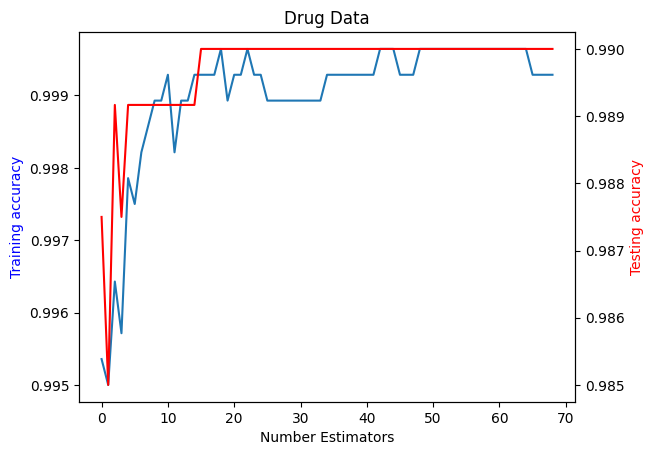

In [60]:
get_accuracy_bag(X, y, "Drug Data")

**The Eye Test vs. Automated Search.**

When you looked at the graph, your eye naturally picked out that massive, beautiful peak right around 4 or 5 estimators. So why did GridSearchCV spit out n_estimators=9?

There are two very specific reasons why your automated grid search chose 9 instead of the peak you saw at 5.

1. Grid Search Evaluates "Cross-Validation" (The Hidden Folds)

    When you look at that red line on your graph, you are likely plotting the accuracy on a single, static test set (or an OOB score calculation from a single training run).

    GridSearchCV, however, doesn't just look at one split. It takes your training data and splits it into multiple chunks (usually 5 folds by default).

    * It trains on 4 folds, tests on the 1st.

    * It trains on a different 4 folds, tests on the 2nd.

    * It does this for all combinations and averages the results.

    While n_estimators=5 might have gotten a "lucky" high score on your specific test split, GridSearchCV found that across all the hidden cross-validation folds, 9 estimators was more stable and reliable on average.

2. The Power of Teamwork: max_depth and n_estimators Interact

    When you looked at the graph, you were likely looking at the impact of changing n_estimators while keeping everything else at its default.

    But in your param_grid, you gave the computer the freedom to change both parameters at the same time.

    A Random Forest tree with unlimited depth is wild and overfits easily, so it needs different tuning. But GridSearchCV discovered a beautiful synergy: by restricting the trees to a shallow max_depth=5, the individual trees became much weaker and more constrained. Because the trees were constrained, the model suddenly needed a few more of them (n_estimators=9) to capture the patterns in the drug data without overfitting.

**So, who is right? You or the Grid Search?**

You are both right, but trust the GridSearchCV result (max_depth=5, n_estimators=9).

A model with 9 shallow trees (max_depth=5) is mathematically much more robust and less prone to overfitting than a model with 5 completely unconstrained, infinitely deep trees. The grid search successfully found a combination that restrains the model's complexity while maximizing its ability to generalize.

**When ARE graphs useful?**

Graphs are actually better than Grid Search for Diagnostics:

* Detecting the Elbow: They show you when adding more trees stops helping (diminishing returns).

* Seeing Overfitting: They show the moment the training and testing lines start moving away from each other.

* Sanity Checks: If Grid Search tells you max_depth=100 is best but your graph shows the test accuracy cratering after depth 10, you know something is wrong with your Grid Search setup.

Don't throw the graphs away! Use the Grid Search to pick your final numbers, but use the Graphs to make sure those numbers actually make sense.

<BR>

___

<BR>

The following codes generate a "Super Graph," that plot the Grid Search results themselves. It’s called a Validation Curve. It shows how the "average" accuracy looks across all those folds.

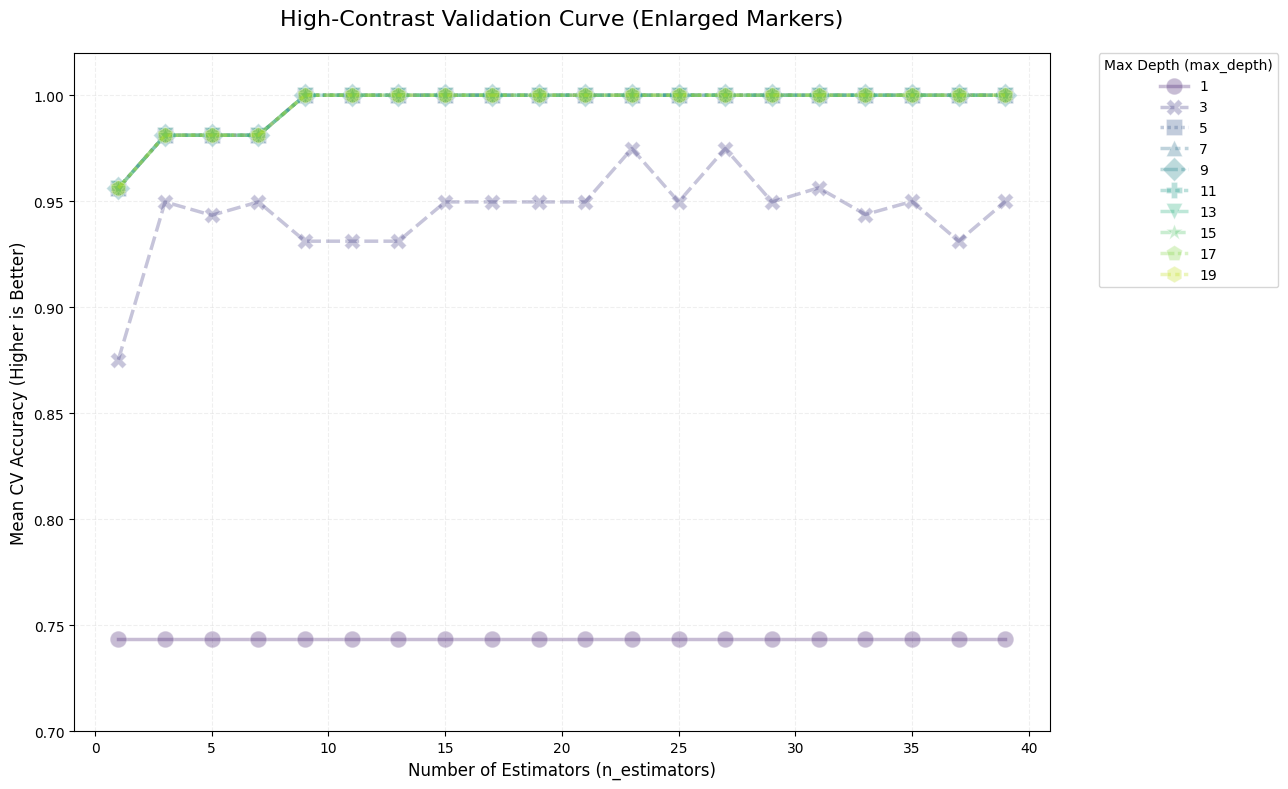

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data (same as your successful run)
cv_results = pd.DataFrame(search.cv_results_)
param_cols = [col for col in cv_results.columns if col.startswith('param_')]
estimators_col = [col for col in param_cols if 'n_estimators' in col][0]
depth_col = [col for col in param_cols if 'max_depth' in col][0]

plot_data = cv_results[param_cols + ['mean_test_score']].copy()
plot_data[depth_col] = plot_data[depth_col].fillna('None').astype(str)

# 2. Map distinct, highly visible shapes to each depth level explicitly
marker_mapping = {
    '1': 'o',      # Circle
    '3': 'X',      # Bold X
    '5': 's',      # Square
    '7': '^',      # Triangle Up
    '9': 'D',      # Diamond
    '11': 'P',     # Bold Plus
    '13': 'v',     # Triangle Down
    '15': '*',     # Star
    '17': 'p',     # Pentagon
    '19': 'h'      # Hexagon
}

plt.figure(figsize=(13, 8))

# 3. Plot with massive, distinct markers
sns.lineplot(
    data=plot_data, 
    x=estimators_col, 
    y='mean_test_score', 
    hue=depth_col, 
    style=depth_col,    
    markers=marker_mapping, # <--- Forces the distinct, high-contrast shapes
    markersize=12,          # <--- Bumps size up significantly so they stand out
    palette="viridis",  
    linewidth=2.5,
    alpha = 0.3
)

plt.title('High-Contrast Validation Curve (Enlarged Markers)', fontsize=16, pad=20)
plt.xlabel('Number of Estimators (n_estimators)', fontsize=12)
plt.ylabel('Mean CV Accuracy (Higher is Better)', fontsize=12)
plt.ylim(0.70, 1.02) 
plt.grid(True, which='both', linestyle='--', alpha=0.2)

# Move legend completely outside out of the way
plt.legend(title='Max Depth (max_depth)', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

plt.show()

**How to read this new graph**

You will see multiple lines on the screen—one for every max_depth you tested.

1. Find the Highest Point: Look for the absolute highest peak on the entire graph. The line color of that peak tells you the optimal max_depth, and its position on the x-axis tells you the optimal n_estimators. This is exactly the coordinate your best_params_ pulled out.

2. Look for Stability: Look at how the lines behave as they move from left to right. A line that stays flat and high is much more stable than a line that peaks sharply and then crashes.

3. See the Interaction: You will visually see why n_estimators=9 and max_depth=5 won. You might notice that while a deeper depth line peaks wildly early on and falls, the max_depth=5 line climbs smoothly and hits a steady, reliable high plateau right around 9 trees.

<BR><BR>

This plot reveals exactly why your grid search picked max_depth=5 and n_estimators=9 over the individual "peaks" you saw on the other graphs.

Let’s dissect this graph together because it exposes a hidden trap that almost all beginner data scientists fall into.

1. Look at the Hidden Overfitting Disaster (The Top Line)

    See that top cyan/blue line representing depths like 7, 9, 11, 13, 15, 17, and 19? They are all perfectly stacked on top of each other, climbing straight up and hitting a perfect 1.00 (100%) cross-validated accuracy at 9 estimators and staying there forever.

    * Why this is a trap: If a model achieves 100% accuracy across multiple validation folds, it usually means the trees are completely unconstrained. They are growing so deep that they have completely memorized your training subsets down to the individual row level.

    * The Danger: A model with 100% training/validation cross-validation like this is hyper-fragile. The moment you expose it to a real-world testing set (like the red testing line from your previous drug data graph), its accuracy will crash because it learned specific noise instead of general patterns.

2. Why max_depth=1 and max_depth=3 Lost

    * max_depth=1 (The Bottom Blue Line): It flatlines down around 74% accuracy. These trees are called "decision stumps"—they only make one single split and stop. They are vastly underfitting the data.

    * max_depth=3 (The Orange Line): It performs much better (~93% to 97%), but it bounces around like a roller coaster. It is highly unstable because 3 levels of depth just aren't quite enough to confidently capture the relationships in your drug data.

3. Why max_depth=5 is the "Goldilocks" Sweet Spot

    Look right at the point where n_estimators=9 sits on the X-axis:

    * By constraining your trees to a maximum depth of 5, you stop them from over-splitting and hitting that dangerous 100% memorization zone.

    * At the same time, it scores high enough to beat out the simpler depth-3 models.

    * It hits a stable plateau where adding more estimators (15, 20, 30 trees) doesn't change the performance.

Your grid search looked at this exact multidimensional landscape and said: "I want to give the user the model that maximizes accuracy without cross-validating at a suspicious 100% variance trap, while keeping the number of estimators as low and computationally efficient as possible."

#### The Ultimate Takeaway
This is why we use validation curves. Your original graph made it look like 5 estimators was a magical anomaly, but this validation curve shows that 9 estimators is where the structural plateaus actually stabilize across all your parameters.

<BR>

___

<BR>

### Is Bagging always used Decision-Trees?

The short answer is we do not always have to use decision trees for bagging. We can mathematically use almost any base classifier or regressor we want — Logistic Regression, K-Nearest Neighbors, Support Vector Machines, or even small Neural Networks.

However, in the real world, we almost always use decision trees.

This comes down to a core concept in machine learning theory: The Bias-Variance Tradeoff. Bagging has a very specific mathematical superpower, and it only works efficiently if fed with a specific type of model.

Here is the breakdown of why we can use other models, but why decision trees remain the undisputed king of bagging.

1. **The Core Rule: Bagging Needs "High Variance, Low Bias" Models**

    The entire purpose of Bagging (Bootstrap Aggregating) is to reduce variance (overfitting) without changing the bias.

    When you average the predictions of hundreds of models together, the random errors cancel each other out. But this averaging trick only works if the individual models make wildly different mistakes when trained on slightly different slices of data.

    * Why Decision Trees fit perfectly: A single unconstrained decision tree is incredibly sensitive to its training data. If you change just 5% of the data rows, the tree will choose completely different split points and look entirely different. It has high variance and low bias. Bagging takes a crowd of these erratic, overfitted trees and averages them into a smooth, rock-solid ensemble (a Random Forest).

    * What happens if you bag a Stable Model (like KNN or Logistic Regression): Models like Logistic Regression have low variance and high bias. If you give Logistic Regression a slightly altered bootstrap sample of your data, the calculated line of best fit will barely change at all. If you bag 100 Logistic Regressions, you are just averaging 100 practically identical lines. Your error rate won't drop, and you have just wasted a massive amount of computational power.

2. **How to use other models in Scikit-Learn**

    If you want to experiment with this yourself, scikit-learn provides a generic wrapper class called BaggingClassifier. You can pass any algorithm into its estimator parameter.

    Here is how you would bag a K-Nearest Neighbors model instead of a decision tree:

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Create a bagged ensemble of 50 KNN models
bagged_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=3),
    n_estimators=50,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagged_knn.fit(X_train, y_train)

3. **Quick Summary: How Different Models React to Bagging**

|Base Estimator|Sensitivity to Bootstrap Sampling|Does Bagging Help?|Verdict|
|---|---|---|---|
|Decision Trees|Extremely High|Massively|The industry standard (creates a Random Forest).|
|Neural Networks|High|Yes|"Works well, but usually too computationally expensive to train dozens of them."|
|K-Nearest Neighbors|Low|Barely|Mostly a waste of CPU cycles because the distance map doesn't shift drastically.|
|Logistic Regression|Extremely Low|No|The averaged model will perform almost identically to a single model.|


So while the math behind bagging is completely open-ended, the structural nature of decision trees makes them the perfect partner for it!